In [ ]:
# GAN for Synthetic MNIST Image Generation

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0
Student roll numbers: 24BAD099 - Rithish A


# Generative Adversarial Network for Synthetic MNIST Images

**Student Roll Number:** 24BAD099  
**Student Name:** Rithish A

## Part A - Dataset Preparation and Image Preprocessing

In [3]:
# Load, inspect, normalize, and batch the MNIST dataset
BATCH_SIZE = 256
BUFFER_SIZE = 60_000
IMAGE_SHAPE = (28, 28, 1)
NOISE_DIM = 100

(train_images, train_labels), (_, _) = keras.datasets.mnist.load_data()
print("Number of training images:", len(train_images))
print("Original image shape:", train_images.shape[1:])
print("Number of classes:", len(np.unique(train_labels)))

train_images = train_images.astype("float32")
train_images = (train_images - 127.5) / 127.5
train_images = np.expand_dims(train_images, axis=-1)

train_dataset = (
    tf.data.Dataset.from_tensor_slices(train_images)
    .shuffle(BUFFER_SIZE, seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Preprocessed image shape:", train_images.shape[1:])
print("Pixel range:", float(train_images.min()), "to", float(train_images.max()))
print("Batches per epoch:", len(train_images) // BATCH_SIZE)

Number of training images: 60000
Original image shape: (28, 28)
Number of classes: 10
Preprocessed image shape: (28, 28, 1)
Pixel range: -1.0 to 1.0
Batches per epoch: 234


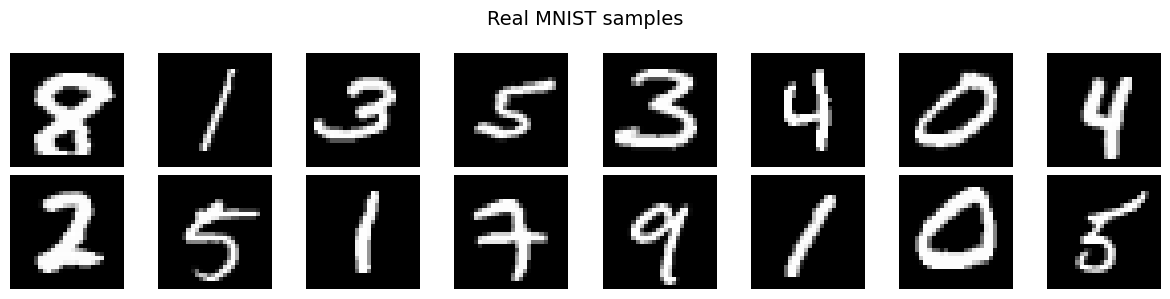

In [4]:
# Display real samples after preprocessing
real_batch = next(iter(train_dataset))
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for axis, image in zip(axes.flat, real_batch[:16]):
    axis.imshow((image.numpy().squeeze() + 1) / 2, cmap="gray")
    axis.axis("off")
fig.suptitle("Real MNIST samples", fontsize=14)
plt.tight_layout()
plt.show()

## Part B - Implementing the Generator

In [5]:
# Build and inspect the Generator

def build_generator():
    return keras.Sequential(
        [
            layers.Input(shape=(NOISE_DIM,)),
            layers.Dense(7 * 7 * 256, use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Reshape((7, 7, 256)),
            layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding="same", use_bias=False, activation="tanh"),
        ],
        name="generator",
    )


generator = build_generator()
noise = tf.random.normal([1, NOISE_DIM], seed=SEED)
initial_generated_image = generator(noise, training=False)
print("Untrained generated image shape:", initial_generated_image.shape)
generator.summary()

Untrained generated image shape: (1, 28, 28, 1)


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

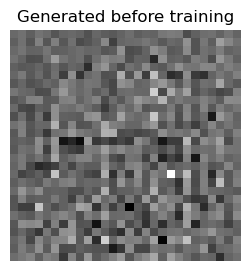

In [6]:
# Display a sample produced before training
plt.figure(figsize=(3, 3))
plt.imshow((initial_generated_image[0, :, :, 0].numpy() + 1) / 2, cmap="gray")
plt.title("Generated before training")
plt.axis("off")
plt.show()

## Part C - Implementing the Discriminator and GAN Model

In [7]:
# Build and compile the Discriminator

def build_discriminator():
    return keras.Sequential(
        [
            layers.Input(shape=IMAGE_SHAPE),
            layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.3),
            layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.3),
            layers.Flatten(),
            layers.Dense(1),
        ],
        name="discriminator",
    )


discriminator = build_discriminator()
discriminator.summary()

cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)
generator_optimizer = keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss


def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

print("Discriminator and GAN losses are ready.")

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

Discriminator and GAN losses are ready.


## Part D - GAN Training and Synthetic Image Generation

In [8]:
# Define one training step and checkpoint visualization
EPOCHS = 20
CHECKPOINT_INTERVAL = 5
NUM_CHECKPOINT_IMAGES = 16
fixed_noise = tf.random.normal([NUM_CHECKPOINT_IMAGES, NOISE_DIM], seed=SEED)

@tf.function
def train_step(real_images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])
    with tf.GradientTape() as generator_tape, tf.GradientTape() as discriminator_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(generated_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    generator_gradients = generator_tape.gradient(gen_loss, generator.trainable_variables)
    discriminator_gradients = discriminator_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))
    return gen_loss, disc_loss


def show_generated_images(epoch, noise=fixed_noise, save_image=True):
    predictions = generator(noise, training=False)
    figure, axes = plt.subplots(4, 4, figsize=(6, 6))
    for axis, image in zip(axes.flat, predictions):
        axis.imshow((image.numpy().squeeze() + 1) / 2, cmap="gray")
        axis.axis("off")
    figure.suptitle(f"Generated images - epoch {epoch}")
    figure.tight_layout()
    if save_image:
        os.makedirs("gan_outputs", exist_ok=True)
        figure.savefig(f"gan_outputs/generated_epoch_{epoch:03d}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(figure)

Epoch 01/20 | Generator loss: 0.6202 | Discriminator loss: 1.3017


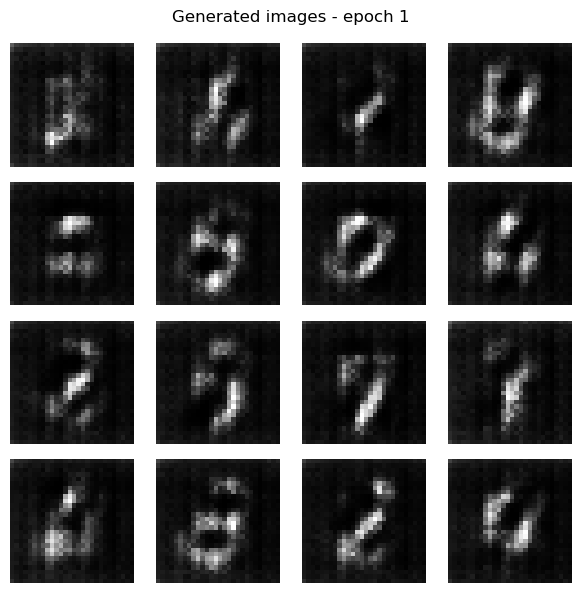

Epoch 02/20 | Generator loss: 0.7195 | Discriminator loss: 1.3236
Epoch 03/20 | Generator loss: 0.7387 | Discriminator loss: 1.3355
Epoch 04/20 | Generator loss: 0.7414 | Discriminator loss: 1.3370
Epoch 05/20 | Generator loss: 0.7611 | Discriminator loss: 1.3156


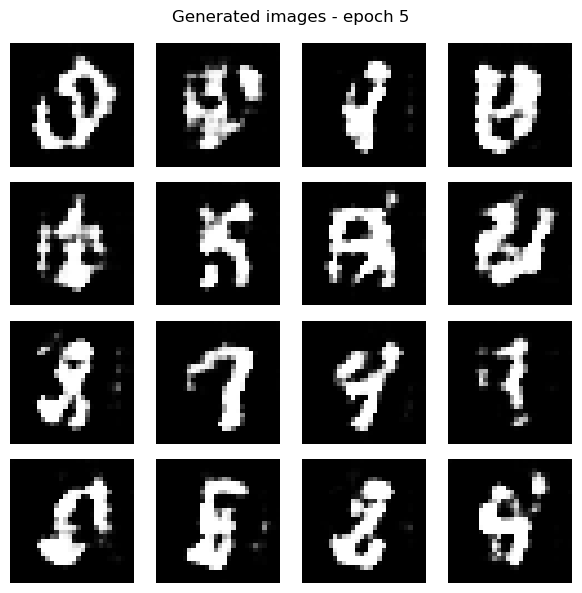

Epoch 06/20 | Generator loss: 0.7834 | Discriminator loss: 1.2964
Epoch 07/20 | Generator loss: 0.8024 | Discriminator loss: 1.2788
Epoch 08/20 | Generator loss: 0.8212 | Discriminator loss: 1.2670
Epoch 09/20 | Generator loss: 0.7950 | Discriminator loss: 1.2915
Epoch 10/20 | Generator loss: 0.7734 | Discriminator loss: 1.3246


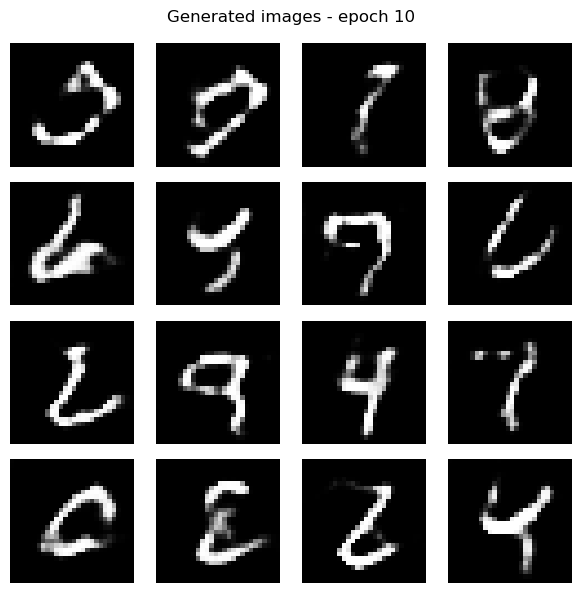

Epoch 11/20 | Generator loss: 0.7561 | Discriminator loss: 1.3372
Epoch 12/20 | Generator loss: 0.7482 | Discriminator loss: 1.3466
Epoch 13/20 | Generator loss: 0.7415 | Discriminator loss: 1.3519
Epoch 14/20 | Generator loss: 0.7534 | Discriminator loss: 1.3453
Epoch 15/20 | Generator loss: 0.7432 | Discriminator loss: 1.3465


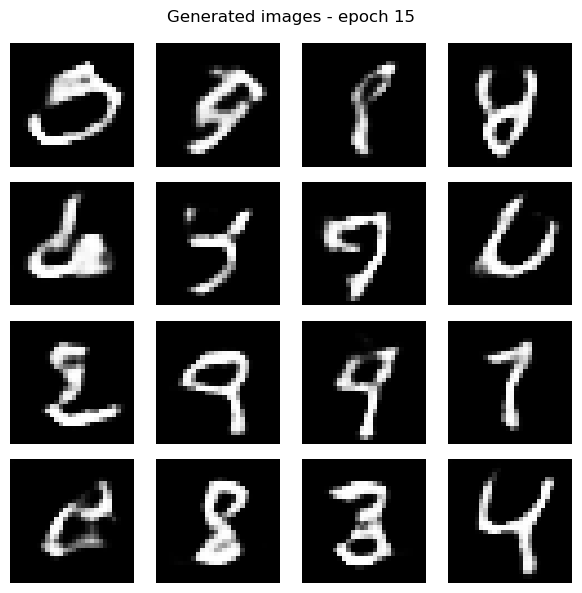

Epoch 16/20 | Generator loss: 0.7355 | Discriminator loss: 1.3518
Epoch 17/20 | Generator loss: 0.7574 | Discriminator loss: 1.3386
Epoch 18/20 | Generator loss: 0.7728 | Discriminator loss: 1.3209
Epoch 19/20 | Generator loss: 0.7429 | Discriminator loss: 1.3446
Epoch 20/20 | Generator loss: 0.7428 | Discriminator loss: 1.3440


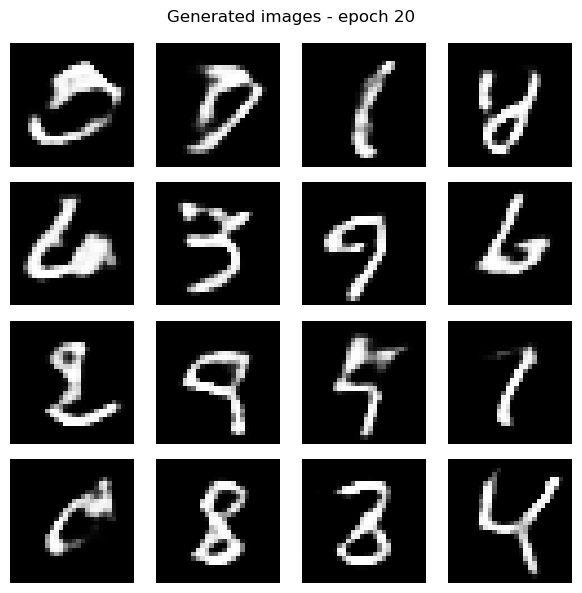

Training complete.


In [9]:
# Train the GAN and record generator/discriminator losses
generator_losses = []
discriminator_losses = []

for epoch in range(1, EPOCHS + 1):
    epoch_generator_losses = []
    epoch_discriminator_losses = []
    for real_images in train_dataset:
        gen_loss, disc_loss = train_step(real_images)
        epoch_generator_losses.append(float(gen_loss))
        epoch_discriminator_losses.append(float(disc_loss))

    mean_gen_loss = float(np.mean(epoch_generator_losses))
    mean_disc_loss = float(np.mean(epoch_discriminator_losses))
    generator_losses.append(mean_gen_loss)
    discriminator_losses.append(mean_disc_loss)

    print(f"Epoch {epoch:02d}/{EPOCHS} | Generator loss: {mean_gen_loss:.4f} | Discriminator loss: {mean_disc_loss:.4f}")
    if epoch == 1 or epoch % CHECKPOINT_INTERVAL == 0 or epoch == EPOCHS:
        show_generated_images(epoch)

print("Training complete.")

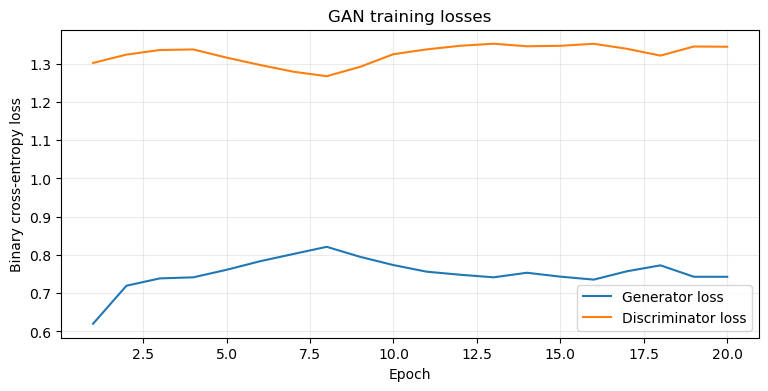

,epoch,generator_loss,discriminator_loss
15,16,0.735493,1.351758
16,17,0.757361,1.338589
17,18,0.772780,1.320891
18,19,0.742911,1.344636
19,20,0.742838,1.344041


In [10]:
# Plot the recorded adversarial losses
loss_table = pd.DataFrame(
    {
        "epoch": np.arange(1, EPOCHS + 1),
        "generator_loss": generator_losses,
        "discriminator_loss": discriminator_losses,
    }
)

plt.figure(figsize=(9, 4))
plt.plot(loss_table["epoch"], loss_table["generator_loss"], label="Generator loss")
plt.plot(loss_table["epoch"], loss_table["discriminator_loss"], label="Discriminator loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("GAN training losses")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

loss_table.tail()

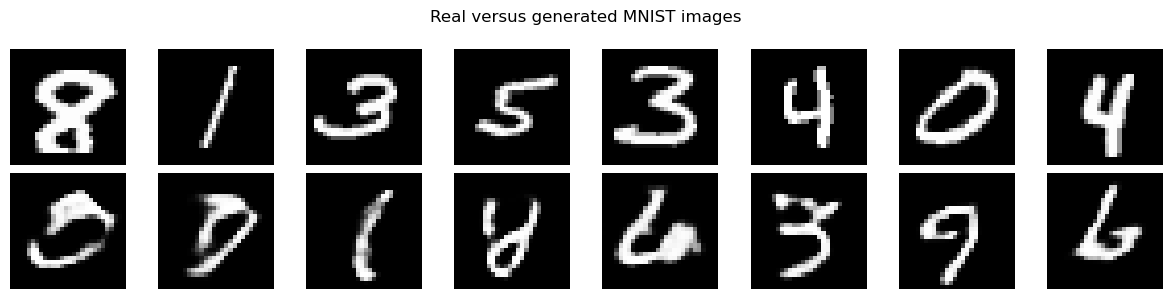

Generated batch pixel standard deviation: 0.5699
Higher non-zero variation indicates that the Generator is producing diverse outputs.


In [11]:
# Compare real and generated images after training
final_generated = generator(fixed_noise, training=False)

figure, axes = plt.subplots(2, 8, figsize=(12, 3))
for axis, image in zip(axes[0], real_batch[:8]):
    axis.imshow((image.numpy().squeeze() + 1) / 2, cmap="gray")
    axis.axis("off")
for axis, image in zip(axes[1], final_generated[:8]):
    axis.imshow((image.numpy().squeeze() + 1) / 2, cmap="gray")
    axis.axis("off")
axes[0, 0].set_ylabel("Real", fontsize=12)
axes[1, 0].set_ylabel("Generated", fontsize=12)
figure.suptitle("Real versus generated MNIST images")
figure.tight_layout()
plt.show()

# Pixel standard deviation is a simple diversity indicator: zero would mean identical outputs.
generated_diversity = float(tf.math.reduce_std(final_generated))
print(f"Generated batch pixel standard deviation: {generated_diversity:.4f}")
print("Higher non-zero variation indicates that the Generator is producing diverse outputs.")

In [12]:
# Save a final batch of generated images and the loss history
os.makedirs("gan_outputs/final_images", exist_ok=True)
final_images_uint8 = np.clip(((final_generated.numpy().squeeze(-1) + 1) * 127.5), 0, 255).astype(np.uint8)

for image_index, image in enumerate(final_images_uint8):
    plt.imsave(
        f"gan_outputs/final_images/generated_{image_index:02d}.png",
        image,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

loss_table.to_csv("gan_outputs/loss_history.csv", index=False)
generator.save("gan_outputs/mnist_generator.keras")
discriminator.save("gan_outputs/mnist_discriminator.keras")

print("Saved 16 final images to gan_outputs/final_images/")
print("Saved loss history and both trained Keras models to gan_outputs/")

Saved 16 final images to gan_outputs/final_images/
Saved loss history and both trained Keras models to gan_outputs/
